# Парное выравнивание

## Импорт библиотек

In [222]:
pip install prettytable

Note: you may need to restart the kernel to use updated packages.


In [194]:
import math
from prettytable import PrettyTable
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


nucleotides = ['A', 'G', 'C', 'T']

# Порядок сдачи домашнего

Вам требуется создать гит репозиторий куда вы будете складывать все ваши домашние. Под каждое домашнее вы создаете отдельную ветку куда вносите все изменения в рамках домашнего. Как только домашнее готово - создаете пулл реквест (обратите внимание что в пулл реквесте должны быть отражены все изменения в рамках домашнего). Ревьювера назначаете из таблицы - https://docs.google.com/spreadsheets/d/1vK6IgEqaqXniUJAQOOspiL_tx3EYTSXW1cUrMHAZFr8/edit?gid=0#gid=0
Перед сдачей проверьте код, напишите тесты. Не забудьте про PEP8, например, с помощью flake8. Задание нужно делать в jupyter notebook.

**Дедлайн - 30 сентября 10:00**

# Введение

**Выравнивание последовательностей** — фундаментальный инструмент в биоинформатике, позволяющий сравнивать биологические последовательности (ДНК, РНК, белки) для выявления сходства, которое может указывать на функциональные, структурные или эволюционные связи между ними.

**Парное выравнивание** подразумевает сравнение двух последовательностей для определения наилучшего соответствия между их элементами (нуклеотидами или аминокислотами). Существует два основных типа парного выравнивания:

- **Глобальное выравнивание**: направлено на выравнивание всей длины двух последовательностей, максимально учитывая все элементы.
- **Локальное выравнивание**: нацелено на поиск наилучшего соответствующего участка внутри двух последовательностей.

В данном домашнем задании мы с вами сконцентрируемся на **глобальном выравнивании**.

### Пример парного выравнивания

Рассмотрим две нуклеотидные последовательности:

```
Последовательность 1 (Seq1): A G C T A C G A
Последовательность 2 (Seq2): G C T A G A
```

**Глобальное выравнивание** (учитывает всю длину последовательностей):

```
Seq1: A G C T A C G A
Seq2: - G C T A - G A
```

### Значение выравнивания последовательностей

- **Эволюционные связи**: Сходство между последовательностями может указывать на общих предков.
- **Функциональные домены**: Выравнивание помогает идентифицировать консервативные участки, важные для функции белка или нуклеиновой кислоты.
- **Геномные исследования**: Используется для аннотации генов, предсказания структур и понимания генетических вариаций.

## Алгоритм выравнивания

- Для автоматизации процесса выравнивания используется **Алгоритм Нидлмана-Вунша**. Он предназначен для глобального выравнивания и использует динамическое программирование для нахождения оптимального выравнивания по всей длине последовательностей. 
- Для оценки сходства при выравнивании белковых последовательностей используется матрица **BLOSUM** (Blocks Substitution Matrix). Матрицы BLOSUM создаются на основе статистического анализа реальных белковых множественных выравниваний последовательностей.

### Пример множественного выравнивания (для построения матрциы BLOSUM)

Рассмотрим нуклеотидные последовательности:

```
Последовательность 1 (Seq1): A G C T A C G T G T C G C T G A A T C T A T G A C T
Последовательность 2 (Seq2): G C T A G A G C A A G G C A A C T G C A T C T
Последовательность 3 (Seq3): A C T G C A C C C A T G A A C C T C G C G C T
Последовательность 4 (Seq4): A C T G C A C C C A T G A A C C T C T C G C T
Последовательность 5 (Seq5): A C T G C A C C C A T G A A C C T C T C G C T
Последовательность 6 (Seq6): A C T G C A C C C A T G A A C C T C T C A C T
Последовательность 7 (Seq7): A C T G C A C C C A T G A A C C T C T C A C T
```

**Множественное выравнивание**:

```
Seq1: A G C T A C G T G T C G C T G A A T C T A T G A C T
Seq2: - G C T A - G A G C A - A G G C A A C T G C A T C T
Seq3: A - C T G - C A C C C - A T G A A C C T C G C G C T
Seq4: A - C T G - C A C C C - A T G A A C C T C T C G C T
Seq5: A - C T G - C A C C C - A T G A A C C T C T C G C T
Seq6: A - C T G - C A C C C - A T G A A C C T C T C A C T
Seq7: A - C T G - C A C C C - A T G A A C C T C T C A C T
```

Перед тем как приступать к реализации парного выравнивания давайте научимся считать матрицу BLOSUM.

# Матрица BLOSUM

## Подсчет частот пар нуклеотидов

### Шаг 1.1: Генерация пар нуклеотидов

Напишите функцию `generate_pairs(alignments)`, которая проходит по всем позициям выравнивания и генерирует все возможные пары нуклеотидов в этой позиции.

**Пример**:

Рассмотрим на примере множественного выравнивания выше:

```
generate_pairs(["A", "A", "G"])
[('A', 'A'), ('A', 'G'), ('A', 'G')]

generate_pairs(["T", "T", "T"])
[('T', 'T'), ('T', 'T'), ('T', 'T')]

generate_pairs(["G", "G", "-"])
[('G', 'G'), ('G', '-'), ('G', '-')]

len(generate_pairs(['A', 'T', 'G', 'G', 'G', 'A', 'A']))
21
```

In [131]:
alignments = ["AGCTACGTGTCGCTGAATCTATGACT", 
              "-GCTA-GAGCA-AGGCAACTGCATCT", 
              "A-CTG-CACCC-ATGAACCTCGCGCT",
              "A-CTG-CACCC-ATGAACCTCTCGCT",
              "A-CTG-CACCC-ATGAACCTCTCGCT",
              "A-CTG-CACCC-ATGAACCTCTCACT",
              "A-CTG-CACCC-ATGAACCTCTCACT"
             ]

In [132]:
def generate_pairs(alignments):
    nukleo_pairs = []
    for column in zip(*alignments):
        for first_nukleo in range(len(column)):
                for second_nukleo in range (first_nukleo + 1, len(column)):
                    nukleo_pairs.append((column[first_nukleo], column[second_nukleo]))
    return nukleo_pairs

#### Tests <span style="color:yellow">generate_pairs</span> function

In [26]:
assert generate_pairs(["A", "G", '-']) == [('A', 'G'), ('A', '-'), ('G', '-')]
assert generate_pairs(["AF", "G-", '-G']) == [('A', 'G'), ('A', '-'), ('G', '-'), ('F', '-'), ('F', 'G'), ('-', 'G')]

### Шаг 1.2: Подсчет частот пар

Используйте полученные пары для подсчета частоты каждой пары нуклеотидов. Создайте словарь `pair_counts`, где ключом является кортеж из двух нуклеотидов, а значением — количество их совместных появлений. Пропуски в выравнивании нужно пропускать (если один из символ в выравнивании `'-'`)

**Подсказка**: Учитывайте, что матрица симметрична, поэтому пары `('A','G')` и `('G','A')` должны считаться одинаковыми.

**Пример**:

```
pair_counts = count_pairs(alignments)
pair_counts
{('A', 'A'): 38, ('G', 'G'): 16, ('C', 'C'): 57, ('T', 'T'): 39, ('A', 'G'): 11,
 ('C', 'G'): 19, ('A', 'T'): 8, ('C', 'T'): 10, ('A', 'C'): 21, ('G', 'T'): 8}}
```

In [133]:
def count_pairs(alignments):
    pairs_count = {}
    nucleo_pairs = generate_pairs(alignments)

    for pair in nucleo_pairs:
        if '-' in pair:
            continue

        sorted_pair = (pair[1], pair[0]) if (pair[0] > pair[1]) else pair
        
        pairs_count[sorted_pair] = pairs_count.get(sorted_pair, 0) + 1
    
    return pairs_count

#### Tests <span style="color:yellow">count_pairs</span> function

In [28]:
assert count_pairs(["AGCT", "TGCA", "CCGT"]) == {('A', 'T'): 3, ('A', 'C'): 1, ('C', 'T'): 1, ('G', 'G'): 1, ('C', 'G'): 4, ('C', 'C'): 1, ('T', 'T'): 1}
assert count_pairs(["A--C", "TGC-", "CCGT"]) == {('A', 'T'): 1, ('A', 'C'): 1, ('C', 'T'): 2, ('C', 'G'): 2}
assert count_pairs(["A"]) == {}

## Вычисление ожидаемых частот

Реализуйте функцию `calculate_frequencies`, которая будет вычислять частоту нуклеотида по множественному выравниванию

**Пример**:

```
freqs = calculate_frequencies(alignments)
print("Частоты:")
for x, freq in freqs.items():
    print(f"{x}: {freq:.4f}")
    
Частоты:
A: 0.2439
G: 0.1585
C: 0.3780
T: 0.2195
```

In [150]:
def calculate_frequencies(alignments):
    frequency = {}

    for chain in alignments:
        for nucleo in chain:
            if (nucleo != '-'):
                frequency[nucleo] = frequency.get(nucleo, 0) + 1

    total_count = sum(frequency.values())
    
    return {key: count / total_count for key, count in frequency.items()}

#### Tests <span style="color:yellow">calculate_frequencies</span> function

In [151]:
assert calculate_frequencies(["AGCT", "TGCA", "CCGT"]) == {'A': 4/24, 'G': 6/24, 'C': 8/24, 'T': 6/24}
assert calculate_frequencies(["A--C", "TGC-", "CCGT"]) == {'A': 1/9, 'C': 4/9, 'T': 2/9, 'G': 2/9}
assert calculate_frequencies([]) == {}

##  Расчет логарифмических коэффициентов

- Для каждой пары нуклеотидов `(x, y)` вычислите логарифмический коэффициент замены по формуле:


$$S(x, y) = scale * \log_2 \left( \frac{observed\_freq[x, y]}{expected\_freq[x, y]} \right)$$

- Здесь `observed_freq` — наблюдаемая частота пары из `pair_counts` деленное на общее количество пар, а `expected_freq` — ожидаемая частота, которую можно вычислить как `expected_freq[x, y] = freqs[x] * freqs[y]`

- Для удобства представления округлите значения `S(x, y)` до целых чисел, умножив на масштабный фактор (например, 3).

**Пример:**

```python
scores = calculate_scores(pair_counts, freqs)
scores
{('A', 'A'): 4, ('G', 'G'): 4, ('C', 'C'): 2, ('T', 'T'): 6, ('A', 'G'): 1,
 ('C', 'G'): 1, ('A', 'T'): -1, ('C', 'T'): -2, ('A', 'C'): 0, ('G', 'T'): 0}
```


In [184]:
def count_normed_freq(pair_counts, freqs, pair, total_pairs_count):
    return (pair_counts[pair] / total_pairs_count) / (freqs[pair[0]] * freqs[pair[1]])


def calculate_scores(pair_counts, freqs, scale=3):
    scores = {}
    total_pairs_count = sum(pair_counts.values())

    for pair in pair_counts:
        scores[pair] = round(scale * math.log(count_normed_freq(pair_counts, freqs, pair, total_pairs_count), 2))
    
    return scores

calculate_scores(count_pairs(alignments), calculate_frequencies(alignments))

{('A', 'A'): 5,
 ('G', 'G'): 5,
 ('C', 'C'): 3,
 ('T', 'T'): 6,
 ('A', 'G'): 1,
 ('C', 'G'): 0,
 ('A', 'T'): -4,
 ('C', 'T'): -4,
 ('A', 'C'): -1,
 ('G', 'T'): -1}

#### Tests <span style="color:yellow">calculate_scores</span> function

In [173]:
assert calculate_scores(
    {('A', 'C'): 2, ('A', 'G'): 2, ('C', 'G'): 3, ('G', 'T'): 2}, 
    {'A': 0.4, 'C': 0.3, 'G': 0.2, 'T': 0.1}
    ) == {('A', 'C'): 3, ('A', 'G'): 4, ('C', 'G'): 7, ('G', 'T'): 10}

assert calculate_scores(
    {('A', 'C'): 2, ('A', 'G'): 2, ('C', 'G'): 3, ('G', 'T'): 2}, 
    {'A': 0.4, 'C': 0.3, 'G': 0.2, 'T': 0.1}, scale=2
    ) == {('A', 'C'): 2, ('A', 'G'): 3, ('C', 'G'): 5, ('G', 'T'): 7}


## Составление матрицы BLOSUM

### Шаг 4.1: Заполнение матрицы

- Реализуйте функцию `create_blosum_matrix`, для создания BLOSUM матрицы.
- Используйте рассчитанные ранее логарифмические коэффициенты `scores` для заполнения матрицы.
- Учитывайте, что матрица симметрична: `S(x, y) = S(y, x)`.

**Пример:**

```python
blosum_matrix = create_blosum_matrix(scores, nucleotides)
blosum_matrix
{'A': {'A': 4, 'G': 1, 'C': 0, 'T': -1},
 'G': {'A': 1, 'G': 4, 'C': 1, 'T': 0},
 'C': {'A': 0, 'G': 1, 'C': 2, 'T': -2},
 'T': {'A': -1, 'G': 0, 'C': -2, 'T': 6}}
```


In [156]:
def create_blosum_matrix(scores, nucleotides):
    blosum_matrix = {}
    
    for first in range(len(nucleotides)):
        for second in range(first, len(nucleotides)):
            score = scores.get((nucleotides[first], nucleotides[second]), scores.get((nucleotides[second], nucleotides[first]), 0))
            blosum_matrix.setdefault(nucleotides[first], {})[nucleotides[second]] = score
            blosum_matrix.setdefault(nucleotides[second], {})[nucleotides[first]] = score
           
    return blosum_matrix

#### Tests <span style="color:yellow">create_blosum_matrix</span> function

In [175]:
assert create_blosum_matrix(
    {
        ('A', 'A'): 4, ('A', 'G'): 1, ('A', 'C'): 0, ('A', 'T'): -1,
        ('G', 'G'): 4, ('G', 'C'): 1, ('G', 'T'): 0,
        ('C', 'C'): 2, ('C', 'T'): -2, ('T', 'T'): 6
    }, ['A', 'C', 'G', 'T']
) == {
    'A': {'A': 4, 'G': 1, 'C': 0, 'T': -1},
    'G': {'A': 1, 'G': 4, 'C': 1, 'T': 0},
    'C': {'A': 0, 'G': 1, 'C': 2, 'T': -2},
    'T': {'A': -1, 'G': 0, 'C': -2, 'T': 6}
}

### Шаг 4.2: Вывод матрицы

- Выведите матрицу BLOSUM в удобочитаемом формате, например, как таблицу с заголовками.

**Пример:**

```python
print_blosum_matrix(blosum_matrix, nucleotides)
    A   G   C   T
A   4   1   0  -1
G   1   4   1   0
C   0   1   2  -2
T  -1   0  -2   6
```

In [195]:
def print_blosum_matrix(matrix, nucleotides):
    table = PrettyTable()
    
    table.align = 'c'
    table.field_names = [" "] + list(matrix.keys())
    
    for row_label, row_values in matrix.items():
        row = [row_label] + [row_values.get(col_label, '-') for col_label in matrix.keys()]
        table.add_row(row)
    
    print(table)

print_blosum_matrix(
    create_blosum_matrix(
        calculate_scores(count_pairs(alignments), calculate_frequencies(alignments)), nucleotides
    ),
    nucleotides
)

+---+----+----+----+----+
|   | A  | G  | C  | T  |
+---+----+----+----+----+
| A | 5  | 1  | -1 | -4 |
| G | 1  | 5  | 0  | -1 |
| C | -1 | 0  | 3  | -4 |
| T | -4 | -1 | -4 | 6  |
+---+----+----+----+----+


## Визуализация результатов

Запустите код для визуализации результатов. Потребуется установить пакеты через `pip install numpy`

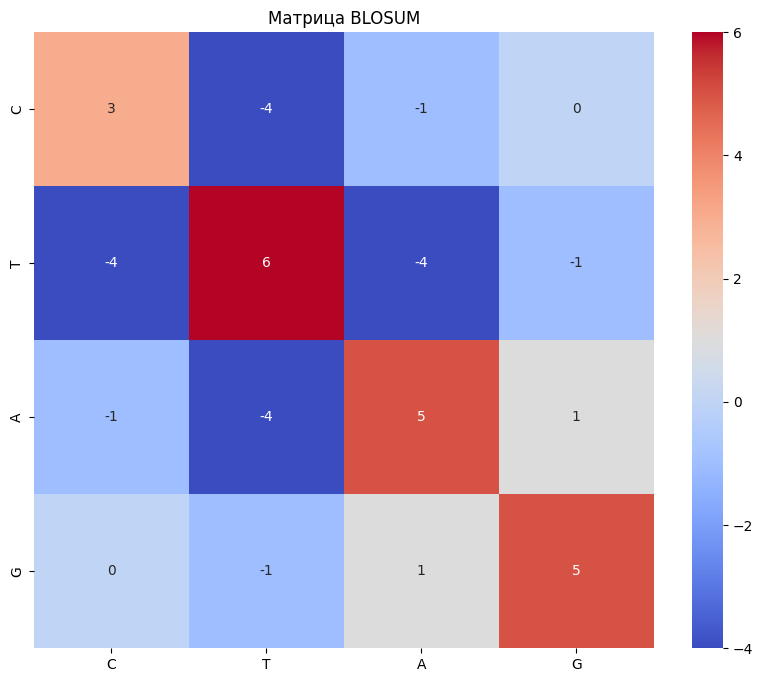

In [196]:
def visualize_blosum_matrix(matrix, nucleotides):
    data = np.array([[matrix[x][y] for y in nucleotides] for x in nucleotides])
    plt.figure(figsize=(10, 8))
    sns.heatmap(data, xticklabels=nucleotides, yticklabels=nucleotides, annot=True, cmap="coolwarm")
    plt.title("Матрица BLOSUM")
    plt.show()

# Пример использования
blosum_matrix = create_blosum_matrix(calculate_scores(count_pairs(alignments), calculate_frequencies(alignments)), list(set(char for s in alignments for char in s if char != '-')))
visualize_blosum_matrix(blosum_matrix, blosum_matrix.keys())

# Реализация алгоритма Нидлмана-Вунша

### Шаг 5: Инициализация матрицы динамического программирования

Теперь перейдём к реализации алгоритма [Нидлмана-Вунша](https://en.wikipedia.org/wiki/Needleman%E2%80%93Wunsch_algorithm).

Реализуйте функцию `init`, которая по $m, n$ и ошибке $\sigma$ строит матрицу c $m + 1$ строкой и $n + 1$ столбцом:

$$A_{m,n} = \begin{pmatrix} 0 & -\sigma & \cdots & -n \sigma \\ -\sigma & 0 & \cdots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ -m\sigma & 0 & \cdots & 0 \end{pmatrix} $$

**Пример:**

```python
print(init(3, 3, 4))
[[0, -4, -8, -12], [-4, 0, 0, 0], [-8, 0, 0, 0], [-12, 0, 0, 0]]
```

In [160]:
def init(rows, cols, gap_penalty=10):
    matrix = []
    for row in range(rows + 1):
        if (row == 0):
            matrix.append([-col*gap_penalty for col in range(cols + 1)])
        else:
            matrix.append([-row*gap_penalty] + [0 for col in range(1, cols + 1)])
    
    return matrix

#### Tests <span style="color:yellow">init</span> function

In [161]:
assert init(3, 3, 4) == [[0, -4, -8, -12], [-4, 0, 0, 0], [-8, 0, 0, 0], [-12, 0, 0, 0]]

### Шаг 6: Заполнение матрицы динамического программирования

Пусть `a` и `b` - две последовательности, которые хотим выравнять. Теперь имея пустую матрицу, нужно научиться её заполнять. Для этого вспомним, как вычисляется очередной элемент матрицы:

$$A_{i \ j} = max \begin{cases} A_{i-1 \ j-1} + s(a_{i},b_{j}) & \ \text{Match / Mismatch}\\ A_{i \ j-1} - \sigma & \ \text{Insertion} \\ A_{i-1\ j} - \sigma & \ \text{Deletion} \end{cases}$$

где $s(a_{i},b_{j})$ - значение матрицы BLOSUM для нуклеотидов $a_{i}$ и $b_{j}$, $\sigma$ - штраф за пропуск символа в выравнивании (параметр)

### Шаг 7: Вычисление значения матрицы

Реализуйте функцию `get_new_score`, которая принимает на вход 5 параметров - `up` ($A_{i-1\ j}$), `left` ($A_{i \ j-1}$), `middle` ($A_{i-1 \ j-1}$), `s_score` ($s(a_{i},b_{j})$), `gap_penalty` ($\sigma$), и вычисляет значение для матрицы $A_{i\ j}$

**Пример:**

```python
print(get_new_score(0, 10, 2, 0, 2))
8
print(get_new_score(-16, -7, -14, 0, 2))
-9
```

In [162]:
def get_new_score(up, left, middle, s_score, gap_penalty):
    return max(middle + s_score, up - gap_penalty, left - gap_penalty)

#### Tests <span style="color:yellow">get_new_score</span> function

In [163]:
assert get_new_score(0, 10, 2, 0, 2) == 8
assert get_new_score(-16, -7, -14, 0, 2) == -9

### Шаг 8 Заполнение матрицы

Реализуйте функцию `align`,  которая на вход принимает две последовательности ДНК, штраф за пропуск ($\sigma$), матрицу BLOSUM и возвращает заполненную матрицу `A`.

**Пример:**

```python
top_seq = "AGTACGCA"
bottom_seq = "TATGC"
gap_penalty = 2

print(align(top_seq, bottom_seq, gap_penalty, blosum_matrix))
[[0, -2, -4, -6, -8, -10, -12, -14, -16],
 [-2, -1, -2, 2, 0, -2, -4, -6, -8],
 [-4, 2, 0, 0, 6, 4, 2, 0, -2],
 [-6, 0, 2, 6, 4, 4, 4, 2, 0],
 [-8, -2, 4, 4, 7, 5, 8, 6, 4],
 [-10, -4, 2, 2, 5, 9, 7, 10, 8]]
```

In [190]:
top_seq = "AGTACGCA"
bottom_seq = "TATGC"
gap_penalty = 2

In [200]:
def get_nucleotide_set(alignments):
    return list(set(char for s in alignments for char in s if char != '-'))

def align(top_seq, bottom_seq, gap_penalty, blosum_matrix):
    matrix = init(len(bottom_seq), len(top_seq), gap_penalty)
    for row in range(1, len(matrix)):
        for column in range(1, len(matrix[row])):
            matrix[row][column] = get_new_score(matrix[row - 1][column], matrix[row][column - 1], matrix[row - 1][column - 1], blosum_matrix[bottom_seq[row - 1]][top_seq[column - 1]], gap_penalty)
    
    return matrix

align(top_seq, bottom_seq, gap_penalty, create_blosum_matrix(calculate_scores(count_pairs([top_seq, bottom_seq]), calculate_frequencies([top_seq, bottom_seq])), nucleotides))
    

[[0, -2, -4, -6, -8, -10, -12, -14, -16],
 [-2, 4, 2, 2, 0, -2, -4, -6, -8],
 [-4, 2, 11, 9, 7, 5, 5, 3, 1],
 [-6, 0, 9, 17, 15, 13, 11, 9, 7],
 [-8, 1, 7, 15, 24, 22, 20, 18, 16],
 [-10, -1, 5, 13, 22, 30, 28, 26, 24]]

### Шаг 9: Построение выравнивания

Теперь имея матрицу выравнивания построим самое выравнивание.

Реализуйте функцию get_alignment, которая по двум последовательностям, матрице выравнивания, штрафа за пропуски, бонусам за совпадение/несовпадение нуклеотидов строит выравнивание.

**Пример:**

```python

top_seq = "AGTACGCA"
bottom_seq = "TATGC"
gap_penalty = 2
sm = align(top_seq, bottom_seq, gap_penalty, blosum_matrix)
aligns = get_alignment(top_seq, bottom_seq, sm, gap_penalty, blosum_matrix)
print(aligns[0])
print(aligns[1])
--TATGC-
AGTACGCA

top_seq = "AGTCTCCCCC"
bottom_seq = "ACTTCTACCCCAGC"
sm = align(top_seq, bottom_seq, gap_penalty, blosum_matrix)
aligns = get_alignment(top_seq, bottom_seq, sm, gap_penalty, blosum_matrix)
print(aligns[0])
print(aligns[1])
ACTTCTACCCCAGC
AGT-CT-CCCC--C
```

In [219]:
def get_alignment(top_seq, bottom_seq, sm, gap_penalty, blosum_matrix):
    i, j = len(bottom_seq), len(top_seq)
    aligned_top = []
    aligned_bottom = []

    while i > 0 and j > 0:
        current_score = sm[i][j]
        s_score = blosum_matrix[bottom_seq[i-1]][top_seq[j-1]]

        if current_score == sm[i-1][j-1] + s_score:
            aligned_top.append(top_seq[j-1])
            aligned_bottom.append(bottom_seq[i-1])
            i -= 1
            j -= 1
        elif current_score == sm[i-1][j] - gap_penalty:
            aligned_top.append('-')
            aligned_bottom.append(bottom_seq[i-1])
            i -= 1
        else:
            aligned_top.append(top_seq[j-1])
            aligned_bottom.append('-')
            j -= 1
            

    while j > 0:
        aligned_top.append(top_seq[j-1])
        aligned_bottom.append('-')
        j -= 1
    while i > 0:
        aligned_top.append('-')
        aligned_bottom.append(bottom_seq[i-1])
        i -= 1

    return ''.join(reversed(aligned_top)), ''.join(reversed(aligned_bottom))

In [220]:
chains = [top_seq, bottom_seq]
scores = calculate_scores(count_pairs(chains), calculate_frequencies(chains))
blosum_matrix = create_blosum_matrix(scores, nucleotides)

sm = align(top_seq, bottom_seq, gap_penalty, blosum_matrix)
aligns = get_alignment(top_seq, bottom_seq, sm, gap_penalty, blosum_matrix)

In [221]:
print(aligns[0])
print(aligns[1])

AGTACGCA
TATG--C-


## Поздравляю! Мы научились выравнивать ДНК!